In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [12]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [15]:
grouped = df.groupby(['age', 'gender']).size().unstack(fill_value=0)

In [16]:
print(grouped)

gender    Female   Male  Unknown/Invalid
age                                     
[0-10)        83     78                0
[10-20)      402    289                0
[20-30)     1114    543                0
[30-40)     2162   1613                0
[40-50)     4811   4874                0
[50-60)     8572   8684                0
[60-70)    11061  11421                1
[70-80)    13985  12081                2
[80-90)    10515   6682                0
[90-100)    2003    790                0


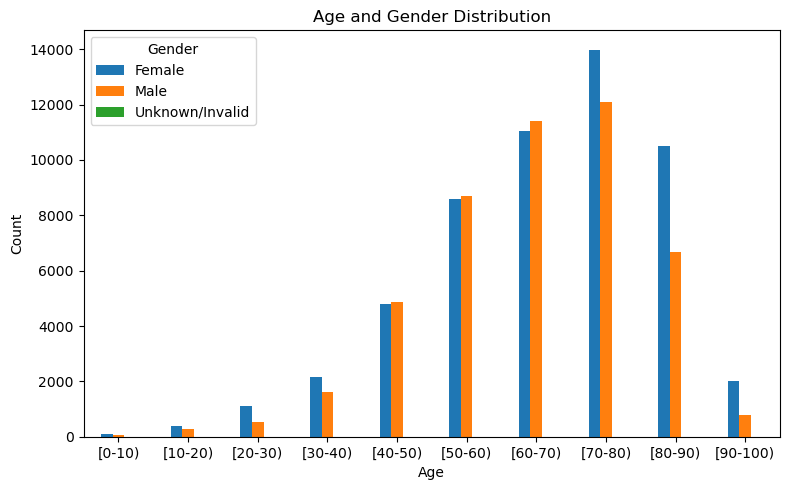

In [17]:
ax = grouped.plot(kind='bar', figsize=(8, 5))

plt.title('Age and Gender Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=0)  
plt.legend(title='Gender')
plt.tight_layout()

plt.show()

1) GROUP THE COLUMNS BY AGE AND GENDER
2) MAKE A BAR CHART SHOWING THE NUMBER OF MEN AD WOMEN FOR EACH RANGE ON THE BAR CHART
3) WITH THE FUNCTION DROP REMOVE SOME UNNECESSARY COLUMNS

In [18]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [21]:
drop_cols = [ 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'weight',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']
df.drop(drop_cols, inplace = True, axis=1)

In [22]:
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,insulin,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,?,...,0,0,250.83,?,?,1,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,0,0,276,250.01,255,9,Up,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,0,1,648,250,V27,6,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,0,0,8,250.43,403,7,Up,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,0,0,197,157,250,5,Steady,Ch,Yes,NO


4) ANALYZE THE COLUMN TIME_IN_HOSPITAL

In [29]:
import seaborn as sns
%matplotlib inline

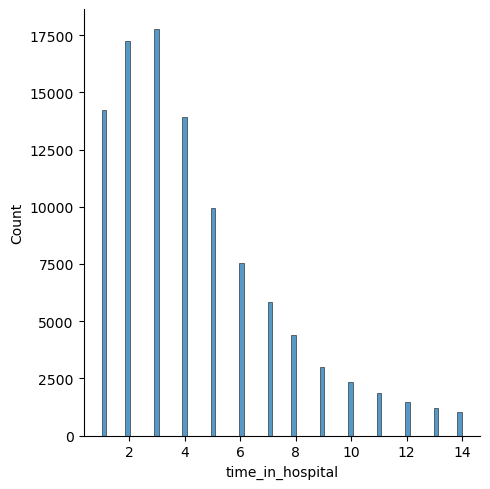

In [30]:
sns.displot(df["time_in_hospital"])

In [31]:
df['time_in_hospital'].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

5) CREATE A NEW DATABASE WITH THE 

In [32]:
nyc = df[['patient_nbr', 'race', 'gender', 'age','payer_code','number_outpatient','number_emergency','number_inpatient','insulin', 'readmitted']].copy()
nyc = nyc.rename(columns={'patient_nbr':'medical_record','payer_code':'insurance'})
print(nyc.head())

   medical_record             race  gender      age insurance  \
0         8222157        Caucasian  Female   [0-10)         ?   
1        55629189        Caucasian  Female  [10-20)         ?   
2        86047875  AfricanAmerican  Female  [20-30)         ?   
3        82442376        Caucasian    Male  [30-40)         ?   
4        42519267        Caucasian    Male  [40-50)         ?   

   number_outpatient  number_emergency  number_inpatient insulin readmitted  
0                  0                 0                 0      No         NO  
1                  0                 0                 0      Up        >30  
2                  2                 0                 1      No         NO  
3                  0                 0                 0      Up         NO  
4                  0                 0                 0  Steady         NO  


In [34]:
nyc.head()

,medical_record,race,gender,age,insurance,number_outpatient,number_emergency,number_inpatient,insulin,readmitted
0,8222157,Caucasian,Female,[0-10),?,0,0,0,No,NO
1,55629189,Caucasian,Female,[10-20),?,0,0,0,Up,>30
2,86047875,AfricanAmerican,Female,[20-30),?,2,0,1,No,NO
3,82442376,Caucasian,Male,[30-40),?,0,0,0,Up,NO
4,42519267,Caucasian,Male,[40-50),?,0,0,0,Steady,NO


In [ ]:
6) THIS NEW DATA BASE IDENTIFY NUMBER PATIENT BY OUT,INP AND EMERGENCY.

In [51]:
date_cols = ['number_outpatient', 'number_inpatient', 'number_emergency']
nyc[date_cols] = nyc[date_cols].apply(pd.to_datetime, errors='coerce')


result = (
    df.groupby('age')[date_cols]
      .nunique()  
      .reset_index()
)

print("\nUnique days per person in each column:")
print(result)


Unique days per person in each column:
        age  number_outpatient  number_inpatient  number_emergency
0    [0-10)                  2                 3                 3
1   [10-20)                  8                10                 8
2   [20-30)                 14                21                11
3   [30-40)                 14                15                22
4   [40-50)                 24                16                21
5   [50-60)                 23                15                18
6   [60-70)                 29                14                19
7   [70-80)                 25                14                10
8   [80-90)                 30                11                 9
9  [90-100)                 11                11                 8


<Figure size 1000x600 with 0 Axes>

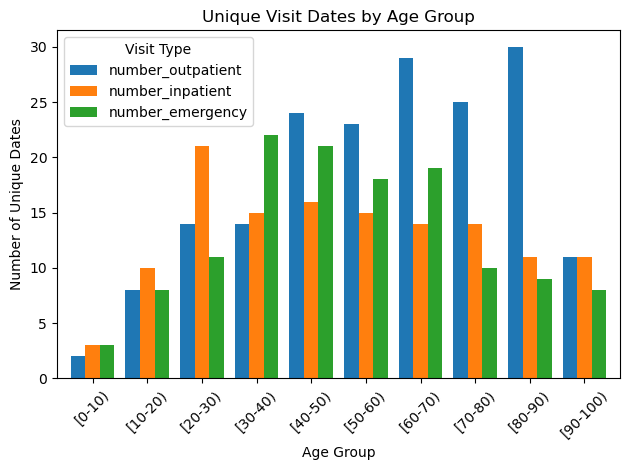

In [52]:
date_cols = ['number_outpatient', 'number_inpatient', 'number_emergency']

nyc[date_cols] = nyc[date_cols].apply(pd.to_datetime, errors='coerce')

result = (
    nyc.groupby('age')[date_cols]
       .nunique()
)

plt.figure(figsize=(10, 6))
result.plot(kind='bar', width=0.8)

plt.title('Unique Visit Dates by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Unique Dates')
plt.xticks(rotation=45)
plt.legend(title='Visit Type')
plt.tight_layout()
plt.show()

According to the graphic, outpatient visits for diabetes are highest among individuals aged 80–90. In contrast, individuals aged 20–30 account for the most emergency visits, while those aged 30–40 have the highest number of inpatient visits.”

In [ ]:
Females show a higher prevalence of diabetes than males from early life through age 40, and again from age 70 into later life.”